# Part 1: Selecting and analyzing the dataset

I have chosen a simple dataset, which you can find in the following [link](https://archive.ics.uci.edu/dataset/186/wine+quality)
This dataset has variables about the wine and its quality
it has a total of 11 features, where one of them is the quality, which is measured from 1 to 10, where 1 is bad and 10 really good

In [6]:
from ucimlrepo import fetch_ucirepo 
import matplotlib.pyplot as plt
import tensorflow as tf
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.linear_model import LinearRegression

from sklearn.model_selection import train_test_split
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import MinMaxScaler

from sklearn.metrics import  mean_squared_error, mean_absolute_error

import os

from NeuralNet import NeuralNet
from helpers import denormalize, save_prediction_to_csv, get_prediction, show_prediction_vs_real_values, create_csv

results_df = create_csv()
metrics = {}

In [2]:
full_file_path = '/Users/hjaviersarmientoy/.cache/kagglehub/datasets/yasserh/wine-quality-dataset/versions/1/WineQT.csv'
df = pd.read_csv(full_file_path)

# Display the first few rows to confirm the import was successful
print(df.head())

   fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  \
0            7.4              0.70         0.00             1.9      0.076   
1            7.8              0.88         0.00             2.6      0.098   
2            7.8              0.76         0.04             2.3      0.092   
3           11.2              0.28         0.56             1.9      0.075   
4            7.4              0.70         0.00             1.9      0.076   

   free sulfur dioxide  total sulfur dioxide  density    pH  sulphates  \
0                 11.0                  34.0   0.9978  3.51       0.56   
1                 25.0                  67.0   0.9968  3.20       0.68   
2                 15.0                  54.0   0.9970  3.26       0.65   
3                 17.0                  60.0   0.9980  3.16       0.58   
4                 11.0                  34.0   0.9978  3.51       0.56   

   alcohol  quality  Id  
0      9.4        5   0  
1      9.8        5   1  
2      9

In [43]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1143 entries, 0 to 1142
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1143 non-null   float64
 1   volatile acidity      1143 non-null   float64
 2   citric acid           1143 non-null   float64
 3   residual sugar        1143 non-null   float64
 4   chlorides             1143 non-null   float64
 5   free sulfur dioxide   1143 non-null   float64
 6   total sulfur dioxide  1143 non-null   float64
 7   density               1143 non-null   float64
 8   pH                    1143 non-null   float64
 9   sulphates             1143 non-null   float64
 10  alcohol               1143 non-null   float64
 11  quality               1143 non-null   int64  
 12  Id                    1143 non-null   int64  
dtypes: float64(11), int64(2)
memory usage: 116.2 KB


In [3]:
df = df.drop(columns=['Id'], axis=1)

scaler = MinMaxScaler(feature_range=(0.1, 0.9))
df_scaled = pd.DataFrame(scaler.fit_transform(df), columns=df.columns)

Xs = df_scaled.iloc[:, :-1]  # Select all columns except the last one
ys = df_scaled.iloc[:, -1]   # Select only the last column

In [45]:
ys.info()

<class 'pandas.core.series.Series'>
RangeIndex: 1143 entries, 0 to 1142
Series name: quality
Non-Null Count  Dtype  
--------------  -----  
1143 non-null   float64
dtypes: float64(1)
memory usage: 9.1 KB


In [46]:
Xs.isna().sum()

fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
dtype: int64

In [47]:
ys.isna().sum()

np.int64(0)

In [48]:
ys.tail

<bound method NDFrame.tail of 0       0.42
1       0.42
2       0.42
3       0.58
4       0.42
        ... 
1138    0.58
1139    0.58
1140    0.42
1141    0.58
1142    0.42
Name: quality, Length: 1143, dtype: float64>

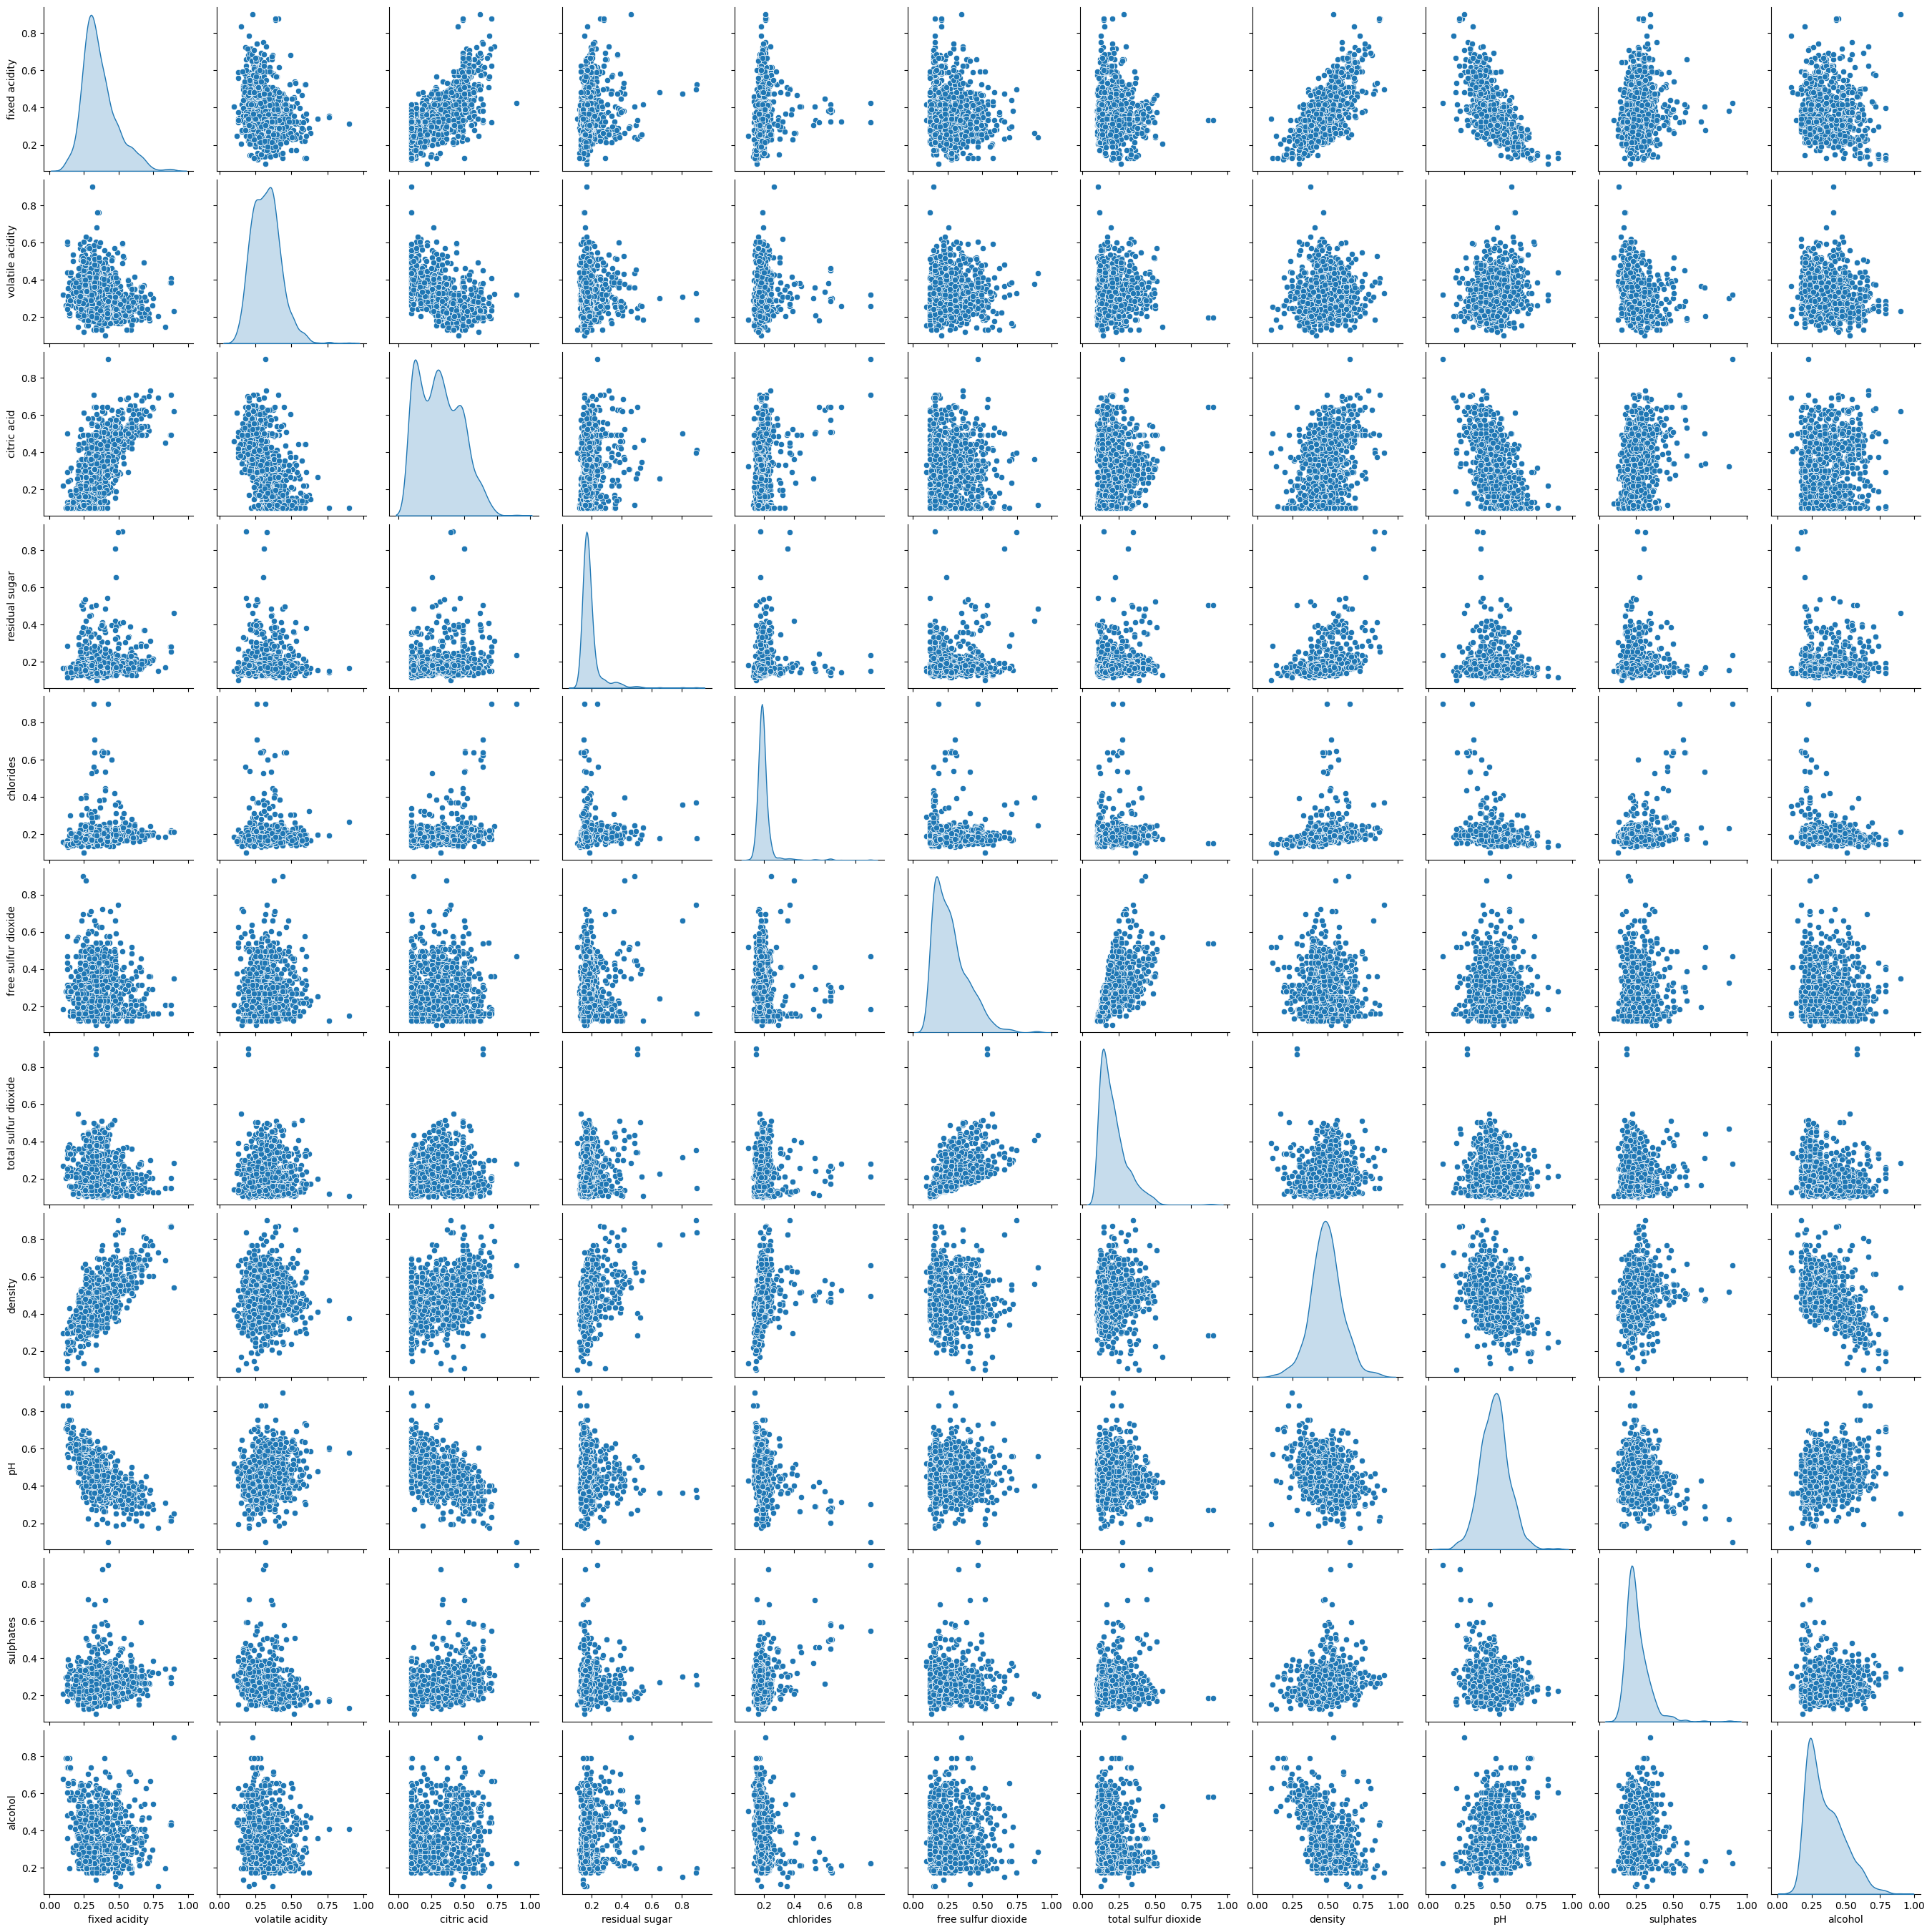

In [49]:
sns.pairplot(Xs[
    Xs.columns
], diag_kind='kde')


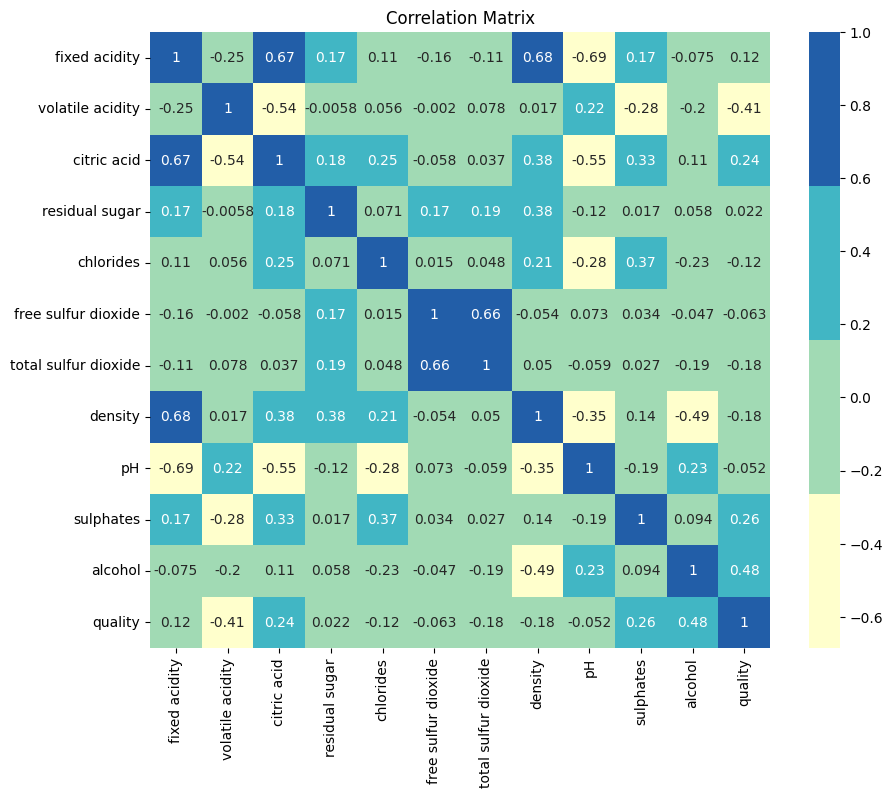

In [50]:
# Create a custom colormap with modified color intensity
custom_cmap = sns.color_palette(['#ffffcc', '#a1dab4', '#41b6c4', '#225ea8'])
correlation_matrix = df.corr()

# Create a heatmap with the custom colormap
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap=custom_cmap)
plt.title('Correlation Matrix')
plt.show()

In [5]:
Xs.describe().transpose()

,count,mean,std,min,25%,50%,75%,max
fixed acidity,1143.0,0.362734,0.123724,0.1,0.276991,0.333628,0.418584,0.9
volatile acidity,1143.0,0.325391,0.098429,0.1,0.249315,0.319178,0.384932,0.9
citric acid,1143.0,0.314691,0.157349,0.1,0.172000,0.300000,0.436000,0.9
residual sugar,1143.0,0.189433,0.074297,0.1,0.154795,0.171233,0.193151,0.9
chlorides,1143.0,0.200077,0.063128,0.1,0.177462,0.189482,0.204174,0.9
free sulfur dioxide,1143.0,0.274513,0.122394,0.1,0.171642,0.243284,0.338806,0.9
total sulfur dioxide,1143.0,0.212833,0.092670,0.1,0.142403,0.187633,0.255477,0.9
density,1143.0,0.491214,0.113073,0.1,0.423054,0.488253,0.556681,0.9
pH,1143.0,0.459694,0.098686,0.1,0.392913,0.459055,0.515748,0.9
sulphates,1143.0,0.256986,0.081628,0.1,0.205389,0.238922,0.291617,0.9


In [52]:
ys.describe().transpose()[['mean', 'std']]

mean    0.525127
std     0.128932
Name: quality, dtype: float64

In [4]:
# Split data into train and test sets
X_train, X_test, y_train, y_test = train_test_split(Xs, ys, test_size=0.2, random_state=42)

## Regression using XGBoost

In [5]:
# Create an XGBRegressor
model = XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=42)

# Fit the model on the training data
model.fit(X_train, y_train)


,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


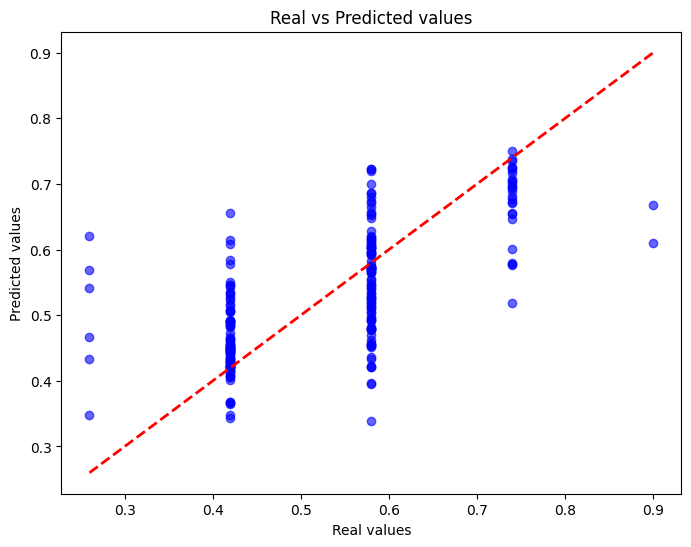

MSE: 0.008215
MAE: 0.065995
MAPE: 13.647513


In [7]:
get_prediction('XGBboost', model, X_test, y_test, y_train, metrics, show_prediction_vs_real=True)

## Regression using Linear Regression

In [9]:
model = LinearRegression()
model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


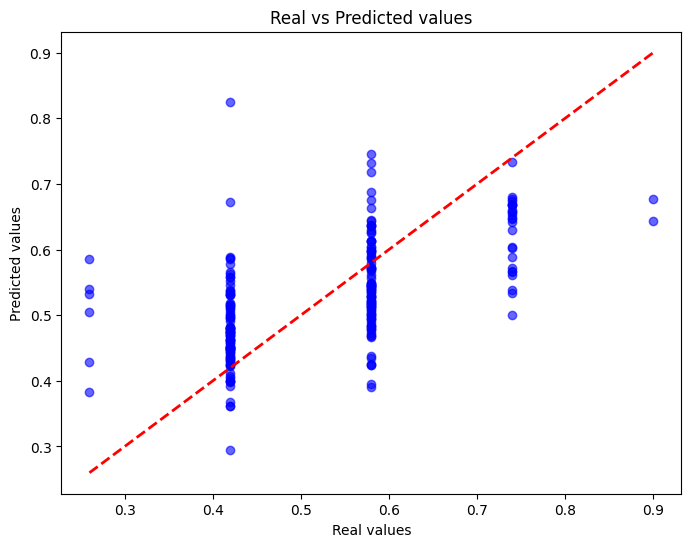

MSE: 0.009729
MAE: 0.076374
MAPE: 15.701838


In [10]:
get_prediction('LinearRegression', model, X_test, y_test, y_train, metrics, show_prediction_vs_real=True)

In [12]:
shape = X_train.shape[1]
shape

11

## Regression using a NN with tensorflow
https://github.com/YanSte/DNN-Wine-Prediction/blob/main/dnn-wine-wine-quality-prediction-with-dnn.ipynb

In [13]:
model = tf.keras.models.Sequential()
model.add(tf.keras.layers.Dense(shape, name="InputLayer"))
model.add(tf.keras.layers.Dense(64, activation='relu', name='Dense_n1'))
model.add(tf.keras.layers.Dense(64, activation='relu', name='Dense_n2'))
model.add(tf.keras.layers.Dense(1, name='Output'))

model.compile(
    optimizer = 'rmsprop',
    loss = 'mse',
    metrics = ['mae', 'mse', 'mape']
)

In [14]:
batch_size = 16
epochs = 50
seed = 123
fit_verbosity = 1

In [15]:
history = model.fit(
    X_train,
    y_train,
    epochs          = epochs,
    batch_size      = batch_size,
    verbose         = fit_verbosity,
    validation_data = (X_test, y_test)
)

Epoch 1/50
58/58 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0258 - mae: 0.1199 - mape: 25.3138 - mse: 0.0258 - val_loss: 0.0183 - val_mae: 0.1086 - val_mape: 19.5452 - val_mse: 0.0183
Epoch 2/50
58/58 ━━━━━━━━━━━━━━━━━━━━ 0s 972us/step - loss: 0.0154 - mae: 0.0978 - mape: 21.2084 - mse: 0.0154 - val_loss: 0.0222 - val_mae: 0.1221 - val_mape: 21.9847 - val_mse: 0.0222
Epoch 3/50
58/58 ━━━━━━━━━━━━━━━━━━━━ 0s 969us/step - loss: 0.0143 - mae: 0.0935 - mape: 20.3610 - mse: 0.0143 - val_loss: 0.0348 - val_mae: 0.1637 - val_mape: 29.8558 - val_mse: 0.0348
Epoch 4/50
58/58 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0139 - mae: 0.0908 - mape: 19.7540 - mse: 0.0139 - val_loss: 0.0175 - val_mae: 0.1067 - val_mape: 19.4603 - val_mse: 0.0175
Epoch 5/50
58/58 ━━━━━━━━━━━━━━━━━━━━ 0s 985us/step - loss: 0.0131 - mae: 0.0895 - mape: 19.4798 - mse: 0.0131 - val_loss: 0.0183 - val_mae: 0.1076 - val_mape: 24.2770 - val_mse: 0.0183
Epoch 6/50
58/58 ━━━━━━━━━━━━━━━━━━━━ 0s 960us/step - loss: 0.0127 - mae: 

Text(0.5, 0, 'epochs')

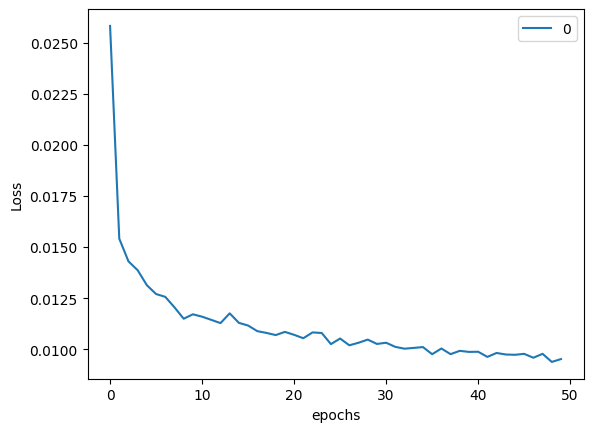

In [16]:
pd.DataFrame(history.history['loss']).plot()
plt.ylabel("Loss")
plt.xlabel("epochs")

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 


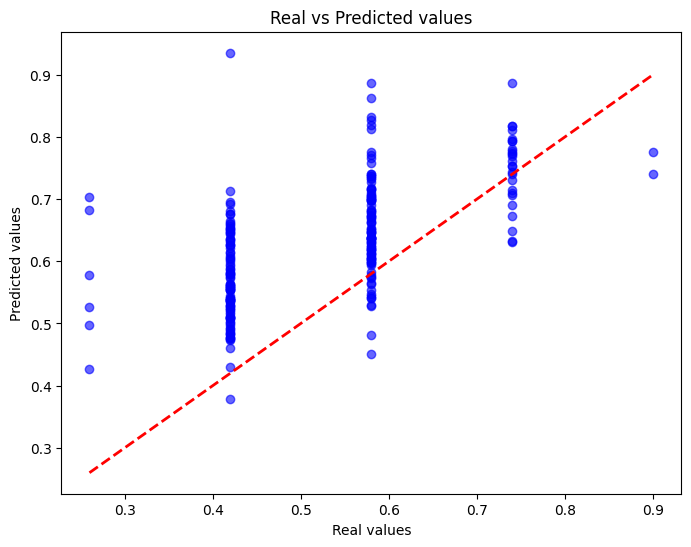

MSE: 0.020474
MAE: 0.116584
MAPE: 33.343274


In [17]:
get_prediction('NN with tensorflow' ,model, X_test.values, y_test.values, y_train, metrics, show_prediction_vs_real=True)

## NN from scratch

In [18]:
X_train = X_train.values
y_train = y_train.values.reshape(-1, 1)

In [19]:
y_train[:5], X_train[:5]

(array([[0.74],
        [0.58],
        [0.42],
        [0.42],
        [0.42]]),
 array([[0.37610619, 0.18767123, 0.548     , 0.14931507, 0.20684474,
         0.50597015, 0.37420495, 0.50117474, 0.45275591, 0.3011976 ,
         0.35846154],
        [0.47522124, 0.20958904, 0.548     , 0.16027397, 0.18146912,
         0.1238806 , 0.10565371, 0.40954479, 0.35826772, 0.29161677,
         0.46923077],
        [0.40442478, 0.20410959, 0.388     , 0.19315068, 0.15876461,
         0.20746269, 0.19328622, 0.42599119, 0.51574803, 0.27245509,
         0.51846154],
        [0.24159292, 0.51643836, 0.132     , 0.17123288, 0.1721202 ,
         0.23134328, 0.13957597, 0.46945668, 0.5976378 , 0.21017964,
         0.28461538],
        [0.31238938, 0.26438356, 0.3       , 0.26438356, 0.22287145,
         0.42238806, 0.33745583, 0.55638767, 0.35826772, 0.21497006,
         0.18615385]]))

In [20]:
nn = NeuralNet(
    layers=[shape, 64, 64, 1],
    epochs=1000,
    learning_rate=0.001,
    momentum=0.9,
    function='relu',
    validation_split=0.2
)

In [21]:
nn.fit(X_train, y_train)

Epoch 0/1000 - Training Error: 0.017034 - Validation Error: 0.018050
Epoch 100/1000 - Training Error: 0.011903 - Validation Error: 0.012709
Epoch 200/1000 - Training Error: 0.008474 - Validation Error: 0.009790
Epoch 300/1000 - Training Error: 0.008471 - Validation Error: 0.010517
Epoch 400/1000 - Training Error: 0.007721 - Validation Error: 0.010139
Epoch 500/1000 - Training Error: 0.007415 - Validation Error: 0.010020
Epoch 600/1000 - Training Error: 0.007173 - Validation Error: 0.010303
Epoch 700/1000 - Training Error: 0.007023 - Validation Error: 0.010939
Epoch 800/1000 - Training Error: 0.006432 - Validation Error: 0.010750
Epoch 900/1000 - Training Error: 0.006038 - Validation Error: 0.011181


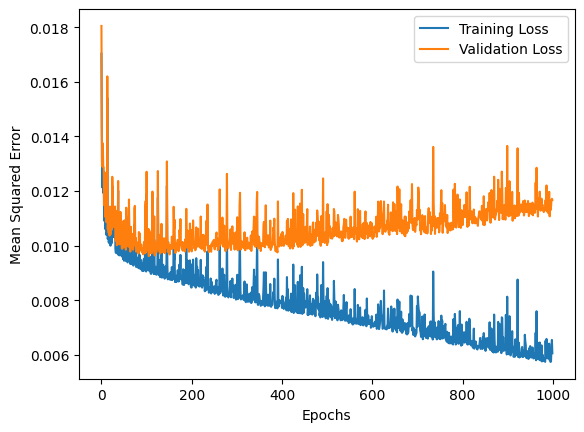

Predictions: [0.46407351 0.43441926 0.40033234 0.39293531 0.47076992 0.68015514
 0.4437394  0.38133834 0.54497336 0.41493118 0.7624023  0.68166216
 0.52823635 0.62078283 0.36180668 0.39826687 0.43993327 0.47862916
 0.43368554 0.78468551 0.58039164 0.57006044 0.4210808  0.70761191
 0.4450509  0.38236171 0.63452403 0.52890384 0.39568571 0.52879547
 0.49134631 0.50145312 0.65282913 0.52442672 0.51207744 0.4136878
 0.48837916 0.55218807 0.77907032 0.37445391 0.64909373 0.43854354
 0.71468367 0.36887298 0.41664394 0.3886282  0.5445565  0.49049629
 0.36772871 0.55084971 0.6503466  0.37813842 0.51421132 0.62135215
 0.49507405 0.73003872 0.49504324 0.60711605 0.53039497 0.44369328
 0.44544048 0.55729353 0.49834977 0.65172482 0.58793883 0.47421314
 0.65479401 0.41367724 0.42028207 0.53429565 0.74228816 0.50195406
 0.43354755 0.49064567 0.44960759 0.46229572 0.56496176 0.51557156
 0.40983066 0.55984066 0.43957043 0.54956137 0.59241397 0.45597105
 0.45022932 0.60078552 0.40573628 0.46649208 0.526

In [22]:
train_loss, val_loss = nn.loss_epochs()
plt.plot(train_loss, label='Training Loss')
plt.plot(val_loss, label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Mean Squared Error')
plt.legend()
plt.show()
predictions = nn.predict(X_test.values)
print("Predictions:", predictions.flatten())

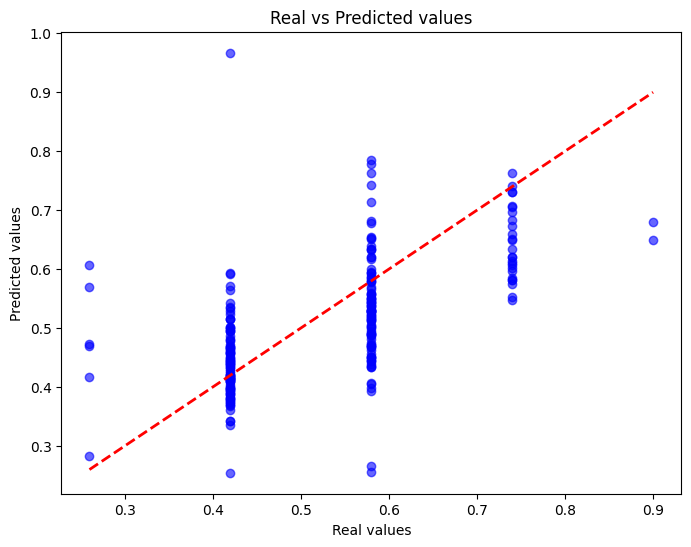

MSE: 0.010728
MAE: 0.075474
MAPE: 24.866314


In [23]:
get_prediction('NN from zero', nn, X_test.values, y_test.values, y_train, metrics, show_prediction_vs_real=True)

In [24]:
nn_2 = NeuralNet(
    layers=[shape, 32, 1],
    epochs=500,
    learning_rate=0.01,
    momentum=0.9,
    function='sigmoid',
    validation_split=0.2
)

In [25]:
nn_2.fit(X_train, y_train)

Epoch 0/500 - Training Error: 0.016241 - Validation Error: 0.017036
Epoch 100/500 - Training Error: 0.011045 - Validation Error: 0.011140
Epoch 200/500 - Training Error: 0.010627 - Validation Error: 0.010822
Epoch 300/500 - Training Error: 0.011090 - Validation Error: 0.011153
Epoch 400/500 - Training Error: 0.010613 - Validation Error: 0.010791


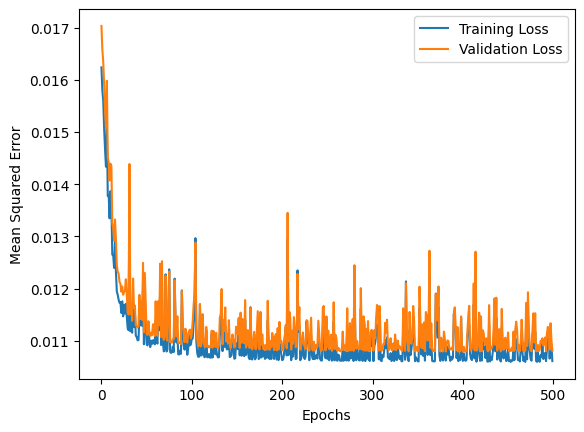

Predictions: [0.47084108 0.38942595 0.46529736 0.42354333 0.60015579 0.67278388
 0.47328199 0.42062038 0.54178115 0.46695445 0.62356043 0.63427354
 0.46682431 0.61073054 0.5565525  0.40101266 0.52191537 0.52745317
 0.49272255 0.64385122 0.5843121  0.57978924 0.44620727 0.65462416
 0.50937581 0.43503888 0.66389368 0.57145942 0.42935949 0.50930381
 0.61550743 0.49223156 0.6695141  0.53466126 0.5040885  0.46527005
 0.49781662 0.58561223 0.72270101 0.65574457 0.64890757 0.46866861
 0.73365867 0.47469119 0.42783849 0.42369158 0.51913221 0.55593962
 0.37461111 0.52916457 0.6421633  0.45933563 0.51201137 0.56012536
 0.53874531 0.63348613 0.49697026 0.53245747 0.57610833 0.45028251
 0.49615908 0.57241976 0.51316657 0.63377338 0.60073566 0.47878379
 0.71278702 0.45057585 0.39283697 0.57557981 0.52032817 0.4683213
 0.56996292 0.57560385 0.44726631 0.44567687 0.55432909 0.54978396
 0.50309527 0.48246658 0.47351049 0.5069115  0.58460474 0.46603287
 0.49678307 0.57948017 0.48317104 0.52434349 0.535

In [26]:
train_loss, val_loss = nn_2.loss_epochs()
plt.plot(train_loss, label='Training Loss')
plt.plot(val_loss, label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Mean Squared Error')
plt.legend()
plt.show()
predictions = nn_2.predict(X_test.values)
print("Predictions:", predictions.flatten())

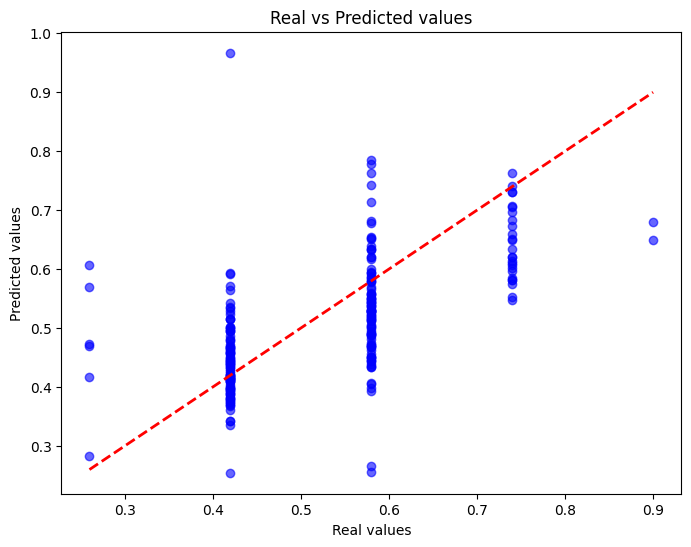

MSE: 0.010728
MAE: 0.075474
MAPE: 24.866314


In [27]:
get_prediction('NN from zero with sigmoid', nn, X_test.values, y_test.values, y_train, metrics, show_prediction_vs_real=True)

In [28]:
save_prediction_to_csv('name', metrics)

## Part 3

Comparing predictions using the three models

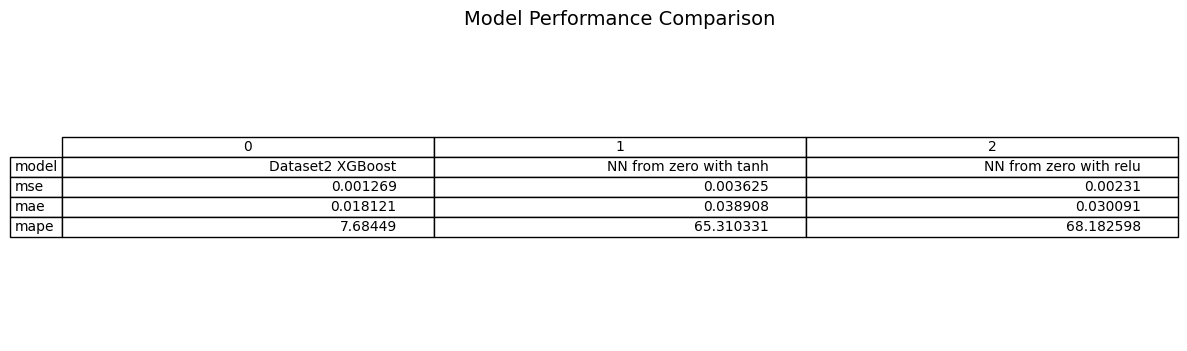

In [29]:
# Read CSV
df = pd.read_csv("model_results_dataset_2.csv")  # change path to your CSV

# If you want to transpose like your example (optional)
df = df.T  # Models = rows, metrics = columns (only if needed)

# Create figure
fig, ax = plt.subplots(figsize=(12, 4))
ax.axis("off")

# Add table
table = ax.table(
    cellText=df.values,
    colLabels=df.columns,
    rowLabels=df.index,
    loc="center"
)

table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1.2, 1.2)

plt.title("Model Performance Comparison", fontsize=14)
plt.show()

References

NN with tensor flow
https://www.datacamp.com/tutorial/one-hot-encoding-python-tutorial
https://www.tensorflow.org/guide/keras/sequential_model
https://numustafa.medium.com/deep-learning-neural-network-for-regression-with-tensorflow-f87968173520

Linear regression with NN
https://www.tensorflow.org/tutorials/keras/regression
https://pyimagesearch.com/2021/05/06/backpropagation-from-scratch-with-python/

https://mmuratarat.github.io/2020-01-09/backpropagation
https://udlbook.github.io/udlbook/


https://github.com/udlbook/udlbook/blob/main/Notebooks/Chap06/6_4_Momentum.ipynb
https://github.com/udlbook/udlbook/blob/main/Notebooks/Chap07/7_2_Backpropagation.ipynb
https://github.com/YanSte/DNN-Wine-Prediction/blob/main/dnn-wine-wine-quality-prediction-with-dnn.ipynb

https://anshulhep.medium.com/make-your-tensorflow-keras-predictions-faster-with-batch-size-8bbd780b9c08

https://www.quora.com/What-is-an-intuitive-explanation-of-momentum-in-training-neural-networks

Implementing cross validation
https://scikit-learn.org/stable/modules/cross_validation.html
https://medium.com/@avijit.bhattacharjee1996/implementing-k-fold-cross-validation-from-scratch-in-python-ae413b41c80d
https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.KFold.html
